# Double Machine Learning + validação de CATE

**Do confounding ao *ranking* honesto de quem tratar.**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/xrhd/mula/blob/main/projects/2026/dml_tutorial/DML_Tutorial.ipynb)

Neste tutorial você vai:
1. Ver por que diferença de médias **não** é efeito causal (confounding);
2. Aprender a mecânica do **Double ML** (Chernozhukov et al., 2018) — equações incluídas;
3. Estimar efeitos heterogêneos (CATE) com `LinearDML` do **EconML**;
4. Avaliar o modelo **sem ter contrafactual**: calibração (Dwivedi et al., 2020) e **Qini** (Radcliffe, 2007) via `econml.validate.DRTester`.

> **Narrativa**: somos um app de delivery. Distribuímos cupons de desconto (`T`) e
> queremos saber o quanto cada cliente gasta a mais por causa do cupom (`Y`) —
> e, principalmente, **para quem** o cupom funciona melhor.

## 0. Setup

In [1]:
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    # !uv pip install --system -q econml lightgbm plotly nbformat
    import subprocess
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "econml", "lightgbm", "plotly", "nbformat"],
        check=True,
    )

import warnings

import matplotlib.pyplot as plt

%matplotlib inline

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.model_selection import train_test_split

from econml.dml import LinearDML
from econml.validate import DRTester

SEED = 42
# econml 0.17 emite RuntimeWarnings numéricos (divide-by-zero em matmul) benignos
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## 1. Por que correlação ≠ efeito causal

O problema clássico: quem recebe cupom **não é sorteado ao acaso** — o time de CRM
manda cupom justamente para quem já é mais engajado. Esse engajamento (`X`) causa
**tanto** receber o cupom **quanto** gastar mais:

```mermaid
graph LR
  X["X: engajamento<br/>(freq., idade da conta, ticket)"] --> T["T: recebeu cupom"]
  X --> Y["Y: gasto"]
  T --> Y
```

`X` é um **confounder**: ele abre um caminho indireto `T ← X → Y` que contamina a
comparação simples entre tratados e controles. A diferença de médias naïve mede
`efeito do cupom + diferença de engajamento`, misturados.

## 2. O DGP — dados com ground truth

Para **ensinar**, simulamos o processo gerador dos dados — assim conhecemos o
efeito verdadeiro `τ(x)` e podemos medir se o método recupera o certo:

$$
X \sim \mathcal{N}(0, \Sigma), \qquad
T \sim \text{Bernoulli}\big(\sigma(f(X))\big) \quad\text{[propensão]}
$$
$$
\tau(x) = 5 + 3\,x_0 \qquad
Y = g(X) + \tau(X)\,T + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 2)
$$

Note: `X` entra em **três** lugares — propensão, `g(·)` e `τ(·)` — reproduzindo o
DAG acima. O efeito `τ(x)` é heterogêneo: clientes já frequentes (`x₀` alto)
respondem melhor ao cupom.

In [2]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def simulate_coupons(n=5000, seed=SEED):
    """Cupom (T binário) -> gasto (Y), com confounding via X e efeito heterogêneo."""
    rng = np.random.default_rng(seed)
    x0 = rng.normal(0, 1, n)                       # frequência passada
    x1 = rng.normal(0, 1, n)                       # idade da conta
    x2 = 0.6 * x0 + 0.8 * rng.normal(0, 1, n)      # ticket médio (correl. com x0)
    X = np.column_stack([x0, x1, x2])

    e_x = sigmoid(0.8 * x0 + 0.4 * x2)             # quem recebe cupom (propensão)
    T = (rng.uniform(size=n) < e_x).astype(int)

    true_tau = 5.0 + 3.0 * x0                      # efeito real: heterogêneo em x0
    g_x = 30 + 4 * x0 + 2 * np.sin(2 * x1) + x2    # baseline de gasto
    Y = g_x + true_tau * T + rng.normal(0, 2, n)

    return X, T, Y, true_tau, e_x


X, T, Y, true_tau, e_x = simulate_coupons()
pd.DataFrame(X, columns=["frequencia", "idade_conta", "ticket_medio"]).describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
frequencia,5000.0,-0.02,1.00,-3.65,-0.69,-0.00,0.63,3.45
idade_conta,5000.0,-0.00,1.01,-4.39,-0.66,-0.02,0.67,4.03
ticket_medio,5000.0,-0.02,0.99,-3.55,-0.70,-0.04,0.63,3.96


In [3]:
fig = go.Figure()
fig.add_histogram(x=e_x[T == 1], name="tratados", opacity=0.7)
fig.add_histogram(x=e_x[T == 0], name="controles", opacity=0.7)
fig.update_layout(
    barmode="overlay", height=350,
    title="Propensão e(x): tratados e controles são populações diferentes",
    xaxis_title="probabilidade prevista de receber cupom", yaxis_title="n",
)
fig.show()

In [4]:
# diferença de médias naïve vs efeito real médio
naive = Y[T == 1].mean() - Y[T == 0].mean()
true_ate = true_tau.mean()

fig = go.Figure(go.Bar(
    x=["naïve: E[Y|T=1]−E[Y|T=0]", "efeito real (ATE)"],
    y=[naive, true_ate], text=[f"{naive:.1f}", f"{true_ate:.1f}"], textposition="auto",
))
fig.update_layout(height=350, title="O viés do confounder em números", yaxis_title="efeito estimado")
fig.show()

print(f"naïve = {naive:.2f} | ATE real = {true_ate:.2f} | viés = {naive - true_ate:+.2f}")

naïve = 10.09 | ATE real = 4.94 | viés = +5.15


A estimativa naïve **sobrestima** o cupom: parte do gasto extra dos tratados já
existiria sem cupom nenhum (é o `4·x₀` do baseline). Precisamos isolar a seta
`T → Y` do DAG — é isso que o DML faz.

## 3. As equações do Double ML

### 3.1 O modelo parcialmente linear

$$
Y = \theta(X)\,T + g(X) + \varepsilon, \qquad T = m(X) + \eta
$$

- `θ(X)` — o CATE, o que queremos;
- `g(X)`, `m(X)` — **nuisance functions**: precisamos delas, mas não interessam em si.

### 3.2 Residualização (o truque central)

Estime $\hat\ell(X) = \hat E[Y|X]$ e $\hat m(X) = \hat E[T|X]$ com ML qualquer
(aqui LightGBM) e subtraia:

$$
\tilde Y = Y - \hat\ell(X), \qquad \tilde T = T - \hat m(X)
$$

O residual `T̃` é a parte do tratamento **não explicada pelo confounder** — é como
se fosse a variação "experimental" que sobra. Regredindo `Ỹ` em `T̃` recuperamos `θ`
sem o viés de `X`.

### 3.3 Por que isso é *debiased*

O estimador resolve o **momento ortogonal de Neyman**:

$$
\psi\big(W; \theta, \eta\big) = \big(\tilde Y - \theta(X)\,\tilde T\big)\,\tilde T, \qquad
\frac{\partial}{\partial \eta}\,E[\psi] = 0
$$

Derivada zerada ⇒ erros na 1ª etapa (nas nuisances) afetam `θ̂` apenas em **2ª
ordem** (entram ao quadrado). Por isso dá para usar ML flexível sem destruir a
inferência — desde que as nuisances sejam razoáveis (produto de erros `o(n^{-1/2})`).

### 3.4 Cross-fitting

Estimar nuisance e `θ` na **mesma** amostra gera viés de overfitting. A solução:
dividir em K folds, estimar nuisances em K−1 folds, aplicar no fold restante, e
repetir (é o `cv=5` do EconML).

```mermaid
flowchart LR
  D[dados] --> K[K folds]
  K --> MY["model_y<br/>E[Y|X]"]
  K --> MT["model_t<br/>E[T|X]"]
  MY --> R["resíduos<br/>Ỹ, T̃"]
  MT --> R
  R --> F["model_final<br/>regressão de Ỹ em T̃·X"]
  F --> C["CATE τ̂(x)"]
```

## 4. Fit com `LinearDML`

`LinearDML` assume `τ(x)` **linear em X** — o que deixa o modelo final legível
(coeficientes = quanto cada feature muda o efeito). As nuisances continuam
não-lineares (LightGBM).

> **Split honesto**: guardamos uma validação que o CATE nunca vê — é nela que o
> `DRTester` vai avaliar tudo.

In [5]:
X_train, X_val, T_train, T_val, Y_train, Y_val = train_test_split(
    X, T, Y, test_size=0.25, random_state=SEED, stratify=T,
)

lgbm_kwargs = dict(n_estimators=50, max_depth=3, random_state=SEED, verbose=-1)
est = LinearDML(
    model_y=LGBMRegressor(**lgbm_kwargs),
    model_t=LGBMClassifier(**lgbm_kwargs),
    discrete_treatment=True,
    cv=5,
    random_state=SEED,
)
est.fit(Y_train, T_train, X=X_train)
est.summary()

,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
X0,3.138,0.105,29.816,0.0,2.932,3.345
X1,0.0,0.08,0.001,1.0,-0.156,0.156
X2,-0.111,0.098,-1.134,0.257,-0.304,0.081
,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
cate_intercept,4.977,0.076,65.47,0.0,4.828,5.126


In [6]:
ate = est.ate(X_val)
ate_lo, ate_hi = est.ate_interval(X_val)
print(f"ATE estimado = {ate:.2f}  IC95% [{ate_lo:.2f}, {ate_hi:.2f}]")
print(f"ATE real     = {true_ate:.2f}   |   naïve era {naive:.2f}")

ATE estimado = 4.88  IC95% [4.73, 5.03]
ATE real     = 4.94   |   naïve era 10.09


In [7]:
order = np.argsort(X_val[:, 0])
x_sorted = X_val[order]
tau_hat = est.effect(x_sorted)
lo, hi = est.effect_interval(x_sorted)
tau_true_sorted = 5.0 + 3.0 * x_sorted[:, 0]

fig = go.Figure()
fig.add_scatter(x=x_sorted[:, 0], y=tau_true_sorted, name="τ(x) real", line=dict(dash="dash"))
fig.add_scatter(x=x_sorted[:, 0], y=tau_hat, name="τ̂(x) LinearDML")
fig.add_scatter(
    x=np.concatenate([x_sorted[:, 0], x_sorted[::-1, 0]]),
    y=np.concatenate([hi, lo[::-1]]),
    fill="toself", fillcolor="rgba(0,114,178,0.2)", line=dict(color="rgba(255,255,255,0)"),
    name="IC 95%", showlegend=True,
)
fig.update_layout(height=400, title="CATE: estimado (com IC) vs real", xaxis_title="x₀ (frequência)", yaxis_title="efeito do cupom")
fig.show()

O DML removeu o viés de nível (ATE certo) e capturou a **heterogeneidade**: o
efeito cresce com `x₀`, como no DGP. Agora a pergunta difícil — e se **não**
soubéssemos o ground truth? Como medir a qualidade do `τ̂(x)`?

## 5. Avaliando CATE sem contrafactual

Nunca observamos `τᵢ` de um indivíduo (não vemos o mesmo cliente com **e** sem
cupom). A saída do `DRTester` é construir um **pseudo-outcome doubly-robust**
que, em média, vale o CATE:

$$
Y_i^{DR} = \hat\mu_1(X_i) - \hat\mu_0(X_i)
+ \frac{T_i\,(Y_i - \hat\mu_1(X_i))}{\hat e(X_i)}
- \frac{(1 - T_i)\,(Y_i - \hat\mu_0(X_i))}{1 - \hat e(X_i)}
\qquad\text{tal que}\qquad
E[Y^{DR}\,|\,X] = \tau(X)
$$

Doubly-robust = basta acertar `μ` **ou** `e` para o alvo estar certo. Com esse
alvo em mãos, avaliar `τ̂` vira um problema supervisionado comum. É exatamente o
que `tester.fit_nuisance(...)` faz (com cross-fitting interno, `cv=5`).

In [8]:
tester = DRTester(
    model_regression=LGBMRegressor(**lgbm_kwargs),
    model_propensity=LGBMClassifier(**lgbm_kwargs),
    cate=est,
    cv=5,
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    tester.fit_nuisance(X_val, T_val, Y_val, X_train, T_train, Y_train)
    tester.get_cate_preds(X_val, X_train)
    res = tester.evaluate_all(Xval=X_val, Xtrain=X_train, n_bootstrap=500)

res.summary()

,treatment,blp_est,blp_se,blp_pval,qini_est,qini_se,qini_pval,autoc_est,autoc_se,autoc_pval,cal_r_squared
0,1,1.292,0.137,0.0,1.045,0.19,0.0,2.806,0.395,0.0,0.814


Leitura rápida do sumário:

- `blp_est` / `blp_pval` — regressão de `Y^DR` em `τ̂`: coeficiente ≈ 1 e p pequeno
  ⇒ o modelo captura heterogeneidade real (**B**est **L**inear **P**redictor);
- `cal_r_squared` — calibração dos subgrupos (seção 6);
- `qini_est` / `qini_pval` — ganho de priorização (seção 7);
- `autoc_est` — variante TOC, idem.

Vamos abrir as duas métricas principais.

## 6. Teste de calibração (Dwivedi et al., 2020)

**Pergunta**: os subgrupos que o modelo diz terem efeitos diferentes *de fato* os têm?

1. Divida a validação em grupos pelos quantis de `τ̂(x)` (ex.: quartis);
2. Em cada grupo `k`, compare o **GATE** (média de `Y^DR` no grupo) com a média
   do `τ̂` predito no grupo;
3. Meça o erro de calibração e a variação entre grupos:

$$
\mathrm{Cal}_G = \sum_k \pi(k)\,\big|\, \mathrm{GATE}_k - \overline{\taû}_k \,\big|,
\qquad
\mathrm{Cal}_O = \sum_k \pi(k)\,\big|\, \mathrm{GATE}_k - \mathrm{ATE} \,\big|
$$
$$
\boxed{\ \mathcal{R}^2_C = 1 - \frac{\mathrm{Cal}_G}{\mathrm{Cal}_O}\ }
$$

**Leitura**: `R²_C → 1` = grupos tão bem separados quanto o modelo afirma
(heterogeneidade real); `R²_C ≤ 0` = os grupos do modelo explicam a variação
**pior** que o ATE constante — a "heterogeneidade" era ruído.

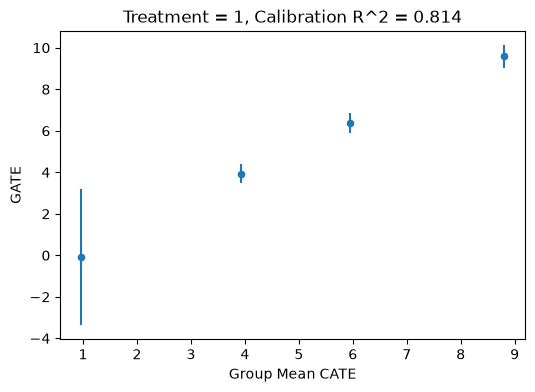

In [9]:
tmt = tester.treatments[1]
ax = res.plot_cal(tmt=tmt)
ax.figure.set_size_inches(6, 4)
plt.show()

In [10]:
# A mesma leitura, em Plotly: pontos perto da reta y=x = bem calibrado
df_cal = res.cal.plot_data_dict[tmt]

fig = go.Figure()
lim = [df_cal[["gate", "g_cate"]].min().min(), df_cal[["gate", "g_cate"]].max().max()]
fig.add_scatter(x=lim, y=lim, mode="lines", name="calibração perfeita", line=dict(dash="dash"))
fig.add_scatter(
    x=df_cal["g_cate"], y=df_cal["gate"], mode="markers+lines", name="grupos (quartis)",
    error_y=dict(type="data", array=1.96 * df_cal["se_gate"]),
    text=[f"grupo {i}" for i in df_cal["ind"]],
)
fig.update_layout(
    height=400, title=f"Calibração: GATE (real, DR) vs τ̂ predito — R²_C = {res.cal.cal_r_squared[0]:.3f}",
    xaxis_title="τ̂ médio predito no grupo", yaxis_title="GATE (E[Y^DR | grupo])",
)
fig.show()

## 7. Qini — o cupom vale mais para quem? (Radcliffe, 2007)

**Pergunta**: se só posso mandar cupom para os top-q% por `τ̂`, quanto de efeito
extra eu ganho vs. mandar aleatoriamente?

Ordene a validação por `τ̂` decrescente e defina, para cada quantil `q`:

$$
\tau_{QINI}(q) = \mathrm{Cov}\big( Y^{DR},\ \mathbb{1}\{\,\taû(Z) \ge \hat\mu(q)\,\} \big)
= q\,\Big(\ E[Y^{DR} \mid \taû \ge \hat\mu(q)] - E[Y^{DR}]\ \Big)
$$
$$
\boxed{\ \mathrm{QINI} = \int_0^1 \tau_{QINI}(q)\,dq\ }
$$

- É o efeito médio no top-q **menos** o ATE, ponderado pelo volume `q` — ou seja,
  **ganho sobre targeting aleatório**;
- `qini_est` é a área sob essa curva; `qini_pval` vem de bootstrap;
- O **TOC/AUTOC** é o mesmo sem o peso `q` (mede só heterogeneidade no topo, sem
  o "tamanho do prêmio" de tratar mais gente).

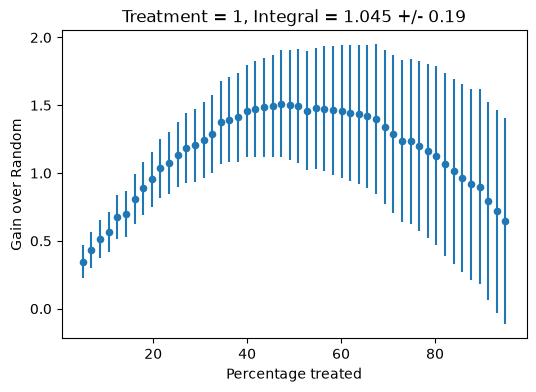

In [11]:
ax = res.plot_qini(tmt=tmt)
ax.figure.set_size_inches(6, 4)
plt.show()

In [12]:
# Qini na mão (~10 linhas) para mostrar que a métrica não é caixa preta
dr_val = tester.dr_val_[:, 0]          # pseudo-outcome DR na validação
cate_val = est.effect(X_val)           # score de priorização

def qini_curve(scores, dr):
    order = np.argsort(-scores)
    dr_sorted = dr[order]
    q = np.arange(1, len(dr) + 1) / len(dr)
    return q, np.cumsum(dr_sorted) / len(dr) - q * dr.mean()

q_manual, curve_manual = qini_curve(cate_val, dr_val)
q_random, curve_random = qini_curve(np.random.default_rng(SEED).normal(size=len(dr_val)), dr_val)

fig = go.Figure()
fig.add_scatter(x=q_manual, y=curve_manual, name="Qini do τ̂(x)")
fig.add_scatter(x=q_random, y=curve_random, name="targeting aleatório (baseline)", line=dict(dash="dash"))
fig.add_scatter(x=[0, 1], y=[0, 0], mode="lines", name="zero", line=dict(color="gray", width=1))
fig.update_layout(height=400, title="Curva Qini calculada à mão (mesma lógica do DRTester)",
                  xaxis_title="fração tratada (top-q por τ̂)", yaxis_title="ganho acumulado sobre aleatório")
fig.show()

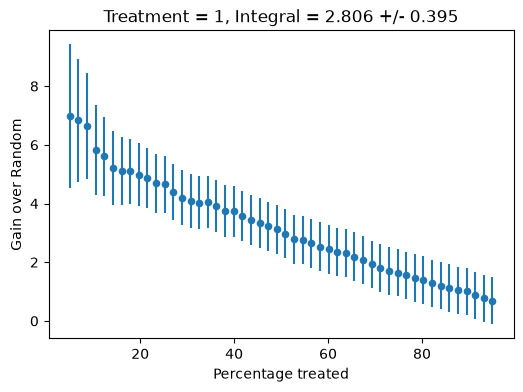

In [13]:
ax = res.plot_toc(tmt=tmt)
ax.figure.set_size_inches(6, 4)
plt.show()

## 8. Diagnóstico: e se o modelo estiver errado?

Métrica que não reprova modelo ruim não serve. Fitamos um CATE **deliberadamente
quebrado** — `LinearDML` em `X` embaralhado (as features deixam de ter relação
com o efeito) — e passamos pelo mesmo `DRTester`:

In [14]:
rng = np.random.default_rng(SEED)
X_bad_train = X_train[rng.permutation(len(X_train))]
X_bad_val = X_val[rng.permutation(len(X_val))]

est_bad = LinearDML(
    model_y=LGBMRegressor(**lgbm_kwargs),
    model_t=LGBMClassifier(**lgbm_kwargs),
    discrete_treatment=True, cv=5, random_state=SEED,
)
est_bad.fit(Y_train, T_train, X=X_bad_train)

tester_bad = DRTester(
    model_regression=LGBMRegressor(**lgbm_kwargs),
    model_propensity=LGBMClassifier(**lgbm_kwargs),
    cate=est_bad, cv=5,
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    tester_bad.fit_nuisance(X_val, T_val, Y_val, X_train, T_train, Y_train)
    tester_bad.get_cate_preds(X_bad_val, X_bad_train)
    res_bad = tester_bad.evaluate_all(Xval=X_bad_val, Xtrain=X_bad_train, n_bootstrap=500)

In [15]:
cols = ["blp_est", "blp_pval", "qini_est", "qini_pval", "autoc_est", "autoc_pval", "cal_r_squared"]
compare = pd.concat(
    [
        res.summary().set_index("treatment").add_prefix("bom_"),
        res_bad.summary().set_index("treatment").add_prefix("ruim_"),
    ],
    axis=1,
)[["bom_" + c for c in cols] + ["ruim_" + c for c in cols]]
compare.round(3)

,bom_blp_est,bom_blp_pval,bom_qini_est,bom_qini_pval,bom_autoc_est,bom_autoc_pval,bom_cal_r_squared,ruim_blp_est,ruim_blp_pval,ruim_qini_est,ruim_qini_pval,ruim_autoc_est,ruim_autoc_pval,ruim_cal_r_squared
treatment,,,,,,,,,,,,,,
1,1.292,0.0,1.045,0.0,2.806,0.0,0.814,0.211,0.783,-0.001,0.497,0.139,0.134,-5.3


In [16]:
_, curve_bad = qini_curve(est_bad.effect(X_bad_val), dr_val)

fig = go.Figure()
fig.add_scatter(x=q_manual, y=curve_manual, name="modelo bom")
fig.add_scatter(x=q_manual, y=curve_bad, name="modelo ruim (X embaralhado)")
fig.add_scatter(x=[0, 1], y=[0, 0], mode="lines", name="zero", line=dict(color="gray", dash="dash"))
fig.update_layout(height=400, title="O teste reprova o modelo quebrado",
                  xaxis_title="fração tratada (top-q)", yaxis_title="ganho acumulado")
fig.show()

O padrão de um modelo que **não** captura heterogeneidade: `cal_r_squared ≤ 0`,
`qini_pval` não significativo e curva Qini colada no zero. É a assinatura que nos
protege de publicar "efeitos heterogêneos" que eram só ruído.

## Recap — checklist de validação de CATE

| métrica | o que pergunta | modelo bom | modelo ruim |
|---|---|---|---|
| **BLP** (`blp_pval`) | `Y^DR` cresce com `τ̂`? | p < 0.05 | p alto |
| **Calibração** (`cal_r_squared`) | GATEs batem com o predito? | → 1 | ≤ 0 |
| **Qini** (`qini_est/pval`) | priorizar por τ̂ ganha do aleatório? | área > 0, p < 0.05 | área ≈ 0 |
| **AUTOC** (`autoc_est/pval`) | há heterogeneidade no topo? | > 0, p < 0.05 | ≈ 0 |

## Quando **não** usar DML

- **Unconfoundedness violado**: DML só corrige confounders **observados** em X.
  Se faltar variável no DAG, nenhum residual salva — considere IV / sensibilidade;
- **Overlap fraco**: regiões com `e(x) ≈ 0` ou `≈ 1` explodem os pesos de `Y^DR`
  (note o clip em 0.01 no código do EconML) — investigue o plot de propensão;
- **Amostra pequena**: cross-fitting + bootstrap de validação precisam de volume.

## Próximos passos

- `CausalForestDML` / `DRLearner` para CATE não-linear;
- Policy learning: transformar `τ̂` em regra de targeting ótima;
- Versão probabilística (DML + Processo Gaussiano, com bandas por indivíduo):
  [`projects/2026/gaussian_process_dml`](https://github.com/xrhd/mula/tree/main/projects/2026/gaussian_process_dml).

## Referências

- Chernozhukov, V. et al. *Double/Debiased Machine Learning for Treatment and
  Structural Parameters*, Econometrics Journal, 2018. [arXiv:1608.00060](https://arxiv.org/abs/1608.00060)
- Dwivedi, R. et al. *Stable Discovery of Interpretable Subgroups via Calibration
  in Causal Studies*, 2020. [arXiv:2008.10109](https://arxiv.org/abs/2008.10109)
- Radcliffe, N. *Using Control Groups to Target on Predicted Lift*, 2007 (Qini)
- Docs: [DRTester](https://www.pywhy.org/EconML/_modules/econml/validate/drtester.html),
  [LinearDML](https://www.pywhy.org/EconML/_modules/econml/dml/dml.html#LinearDML),
  [notebook oficial CATE validation](https://github.com/py-why/EconML/blob/main/notebooks/CATE%20validation.ipynb)